## n 2 n continued 

In [1]:
# check correlation between shots/goals and passes

import pandas as pd
import scipy.stats as stats
import ast

url = "https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv"
df = pd.read_csv(url)

for col in df.columns:
    print(col)

df.head(1)


eventId
subEventName
tags
playerId
matchId
eventName
teamId
matchPeriod
eventSec
subEventId
id
x1
y1
x2
y2


,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0


In [2]:
goals = df.loc[df["tags"].apply(lambda x: "Goal" in x)]

In [3]:
for tag in goals["tags"]:
    if "Goal " in tag or " Goal" in tag:
        print(tag)

['Goal', 'Head/body', 'Opportunity', 'Position: Goal low left', 'Accurate']
['Goal', 'Position: Goal low left', 'Not accurate']
['Goal', 'Left foot', 'Opportunity', 'Position: Goal high left', 'Accurate']
['Goal', 'Position: Goal high left', 'Not accurate']
['Head/body', 'Opportunity', 'Position: Goal high center', 'Accurate']
['Position: Goal high center', 'Accurate']
['Right foot', 'Opportunity', 'Position: Goal low center', 'Accurate']
['Position: Goal low center', 'Accurate']
['Goal', 'Head/body', 'Opportunity', 'Position: Goal low right', 'Accurate']
['Goal', 'Position: Goal low right', 'Not accurate']
['Goal', 'Left foot', 'Opportunity', 'Position: Goal high right', 'Accurate']
['Goal', 'Position: Goal high right', 'Not accurate']
['Goal', 'Right foot', 'Direct', 'Opportunity', 'Position: Goal center right', 'Accurate']
['Goal', 'Position: Goal center right', 'Not accurate']
['Right foot', 'Opportunity', 'Position: Goal low left', 'Accurate']
['Position: Goal low left', 'Accurate

In [4]:
df["tags"] = df["tags"].apply(ast.literal_eval)

In [5]:
# .apply() does not take an instantiated function (fn())

def new_fn(fn):
    return fn(2)

def my_fn(num):
    return num**2

new_fn(my_fn)

4

In [6]:
uniquetags = set()
for taglist in df["tags"]:
    for tag in taglist:
        uniquetags.add(tag)
print(uniquetags)
uniquetags = set([tag for taglist in df["tags"] for tag in taglist])
uniquetags

{'Opportunity', 'High', 'Feint', 'Position: Goal high left', 'Position: Out high left', 'Head/body', 'Left foot', 'Won', 'Position: Goal high center', 'Accurate', 'Sliding tackle', 'Position: Out low left', 'Red card', 'Missed ball', 'Position: Out center right', 'Lost', 'Position: Out center left', 'Position: Post low right', 'Blocked', 'Fairplay', 'Position: Post high left', 'Interception', 'Assist', 'Position: Out high center', 'Free space right', 'Anticipation', 'Free space left', 'Key pass', 'Yellow card', 'Position: Goal high right', 'Position: Post center left', 'Direct', 'Right foot', 'Position: Goal center left', 'Indirect', 'Anticipated', 'Position: Post high right', 'Position: Post center right', 'Take on right', 'Position: Goal low center', 'Second yellow card', 'Goal', 'Through', 'Position: Goal center', 'Position: Post low left', 'Own goal', 'Position: Out low right', 'Neutral', 'Position: Out high right', 'Position: Goal low right', 'Position: Goal center right', 'Danger

{'Accurate',
 'Anticipated',
 'Anticipation',
 'Assist',
 'Blocked',
 'Counter attack',
 'Dangerous ball lost',
 'Direct',
 'Fairplay',
 'Feint',
 'Free space left',
 'Free space right',
 'Goal',
 'Head/body',
 'High',
 'Indirect',
 'Interception',
 'Key pass',
 'Left foot',
 'Lost',
 'Missed ball',
 'Neutral',
 'Not accurate',
 'Opportunity',
 'Own goal',
 'Position: Goal center',
 'Position: Goal center left',
 'Position: Goal center right',
 'Position: Goal high center',
 'Position: Goal high left',
 'Position: Goal high right',
 'Position: Goal low center',
 'Position: Goal low left',
 'Position: Goal low right',
 'Position: Out center left',
 'Position: Out center right',
 'Position: Out high center',
 'Position: Out high left',
 'Position: Out high right',
 'Position: Out low left',
 'Position: Out low right',
 'Position: Post center left',
 'Position: Post center right',
 'Position: Post high center',
 'Position: Post high left',
 'Position: Post high right',
 'Position: Post lo

In [7]:
df["pass"] = (df["eventName"] == "Pass").astype(int)
df["shot"] = (df["eventName"] == "Shot").astype(int)
df["goal"] = ((df["eventName"] == "Shot") & (df["tags"].apply(lambda x: "Goal" in x))).astype(int)
df["acc_pass"] = ((df["eventName"] == "Pass") & (df["tags"].apply(lambda x: "Accurate" in x))).astype(int)
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot,goal,acc_pass
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,1,0,0,1


In [8]:
from math import dist
def get_golden_shot(row:pd.Series):
    is_shot = row["eventName"] == "Shot"
    x_len = 120
    y_len = 75
    x1 = (row["x1"] / 100) * x_len 
    y1 = (row["y1"] / 100) * y_len
    x2 = x_len
    y2 = ((100/ 2) /100) * y_len
    d = dist([x1,y1], [x2,y2])
    
    if is_shot and d <= 18:
        return 1
    else:
        return 0    
    
df['golden_shot'] = df.apply(get_golden_shot,axis=1)
# df["golden_shot"] = df["x1"].apply(get_golden_shot)
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot,goal,acc_pass,golden_shot
0,8,Simple pass,[Accurate],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,1,0,0,1,0


In [9]:
grp = df.groupby(["matchId", "teamId"]).agg(
    shots=("shot","sum"),
    passes=("pass", "sum"),
    goals=("goal", "sum"),
    golden_shots=("golden_shot", "sum"),
    acc_passes=("acc_pass", "sum")    
).reset_index()
grp["perc_acc_pass"] = grp["acc_passes"] / grp["passes"]
grp["perc_gold_shot"] = grp["golden_shots"] / grp["shots"] 
grp

,matchId,teamId,shots,passes,goals,golden_shots,acc_passes,perc_acc_pass,perc_gold_shot
0,"Argentina - Croatia, 0 - 3",Argentina,10,476,0,7,393,0.825630,0.700000
1,"Argentina - Croatia, 0 - 3",Croatia,13,334,3,5,261,0.781437,0.384615
2,"Argentina - Iceland, 1 - 1",Argentina,22,744,1,6,675,0.907258,0.272727
3,"Argentina - Iceland, 1 - 1",Iceland,8,183,1,3,141,0.770492,0.375000
4,"Australia - Peru, 0 - 2",Australia,11,512,0,7,446,0.871094,0.636364
...,...,...,...,...,...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,238,2,1,185,0.777311,0.166667
124,"Uruguay - Russia, 3 - 0",Russia,3,327,0,0,271,0.828746,0.000000
125,"Uruguay - Russia, 3 - 0",Uruguay,12,466,1,5,405,0.869099,0.416667
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,553,0,2,482,0.871609,0.285714


In [10]:
import seaborn as sns, matplotlib.pyplot as plt

def viz_corr(x:str, y:str):
    plt.figure(figsize=(5,3))
    r,p = stats.pearsonr(grp[x], grp[y])
    r2 = r**2
    reg = sns.regplot(data=grp, x=x, y=y, line_kws={"color": "red"})
    text=f"""r={r:.4f}
p={p:.4f}
r2={r2:.4f}"""
    reg.text(
        0.1,
        0.7,
        text,
        transform=reg.transAxes,
        bbox={"boxstyle":"round,pad=0.5", "fc":"white"}
    )
    plt.show()

In [11]:
grp.corr(numeric_only=True)

,shots,passes,goals,golden_shots,acc_passes,perc_acc_pass,perc_gold_shot
shots,1.000000,0.564229,0.210675,0.785044,0.555309,0.392210,0.036478
passes,0.564229,1.000000,0.120015,0.500424,0.995563,0.741263,0.097462
goals,0.210675,0.120015,1.000000,0.220095,0.125879,0.162325,0.147073
golden_shots,0.785044,0.500424,0.220095,1.000000,0.496650,0.357474,0.565483
acc_passes,0.555309,0.995563,0.125879,0.496650,1.000000,0.788865,0.101464
perc_acc_pass,0.392210,0.741263,0.162325,0.357474,0.788865,1.000000,0.098569
perc_gold_shot,0.036478,0.097462,0.147073,0.565483,0.101464,0.098569,1.000000


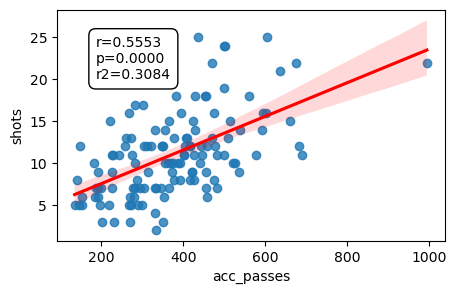

In [12]:
viz_corr("acc_passes", "shots")

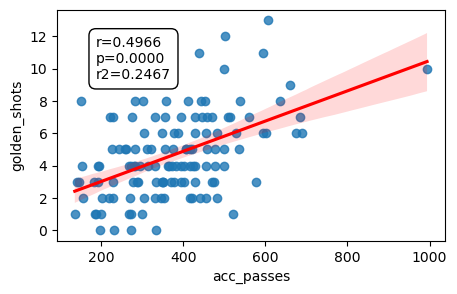

In [13]:
viz_corr("acc_passes", "golden_shots")

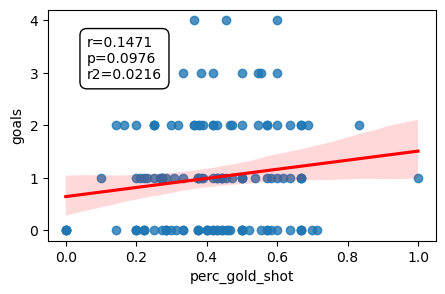

In [14]:
viz_corr("perc_gold_shot", "goals")

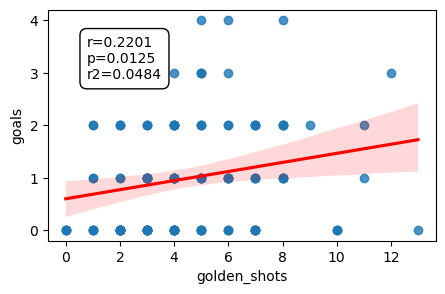

In [15]:
viz_corr("golden_shots", "goals")